# Data pipeline sanity check

Visual + numeric checks on the normalized price tensors built by
`data/data_loader.py` (Jiang, Xu & Liang 2017, §3.2 / Eq. 18).

This notebook only *reads* the cached dataset — it never re-downloads.
The runnable mirror is `notebooks/plot_tensors.py`.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Make the sibling data/ package importable.
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'data'))
import data_loader as dl

ds = dl.build_dataset()   # loads cached raw CSVs; builds panel + splits
print('assets :', ds.tickers)
print('days   :', len(ds.dates), f'({ds.dates[0].date()} -> {ds.dates[-1].date()})')
print('panel  :', ds.panel.shape, '(T, m, F=High,Low,Close)')
print('splits :', ds.splits)

assets : ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'PG', 'AMZN', 'NVDA']
days   : 1254 (2021-07-23 -> 2026-07-22)
panel  : (1254, 8, 3) (T, m, F=High,Low,Close)
splits : Splits(train=(0, 878), val=(878, 1066), test=(1066, 1254))


## 1. Adjusted closes with chronological split boundaries
Confirms clean split/dividend adjustment (no discontinuities) and that the split
is strictly chronological — the test window is the most recent period.

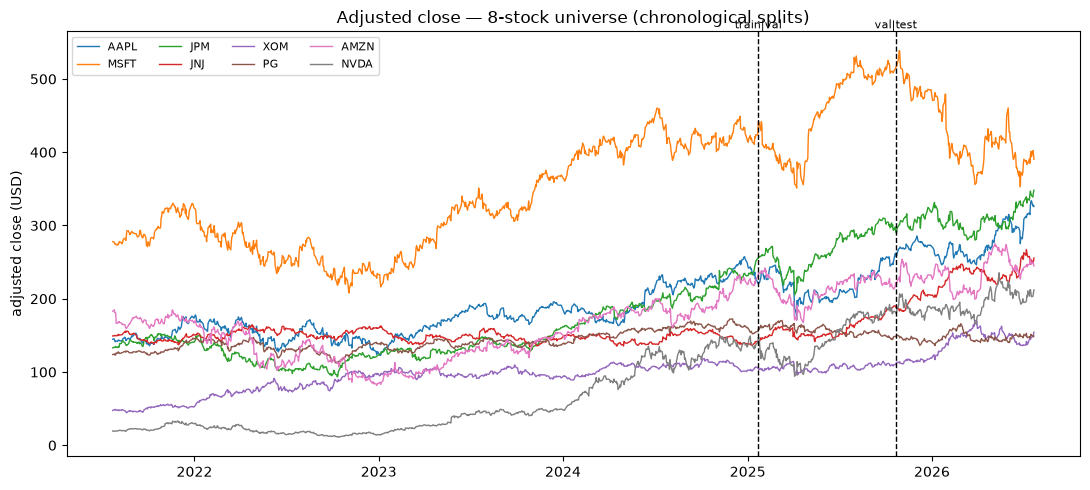

In [2]:
close = ds.panel[:, :, dl.FEATURES.index('Close')]
fig, ax = plt.subplots(figsize=(11, 5))
for i, t in enumerate(ds.tickers):
    ax.plot(ds.dates, close[:, i], label=t, lw=1)
for b, lbl in [(ds.splits.train[1], 'train|val'), (ds.splits.val[1], 'val|test')]:
    ax.axvline(ds.dates[b], color='k', ls='--', lw=1)
    ax.text(ds.dates[b], ax.get_ylim()[1], lbl, fontsize=8, ha='center', va='bottom')
ax.set_title('Adjusted close — 8-stock universe (chronological splits)')
ax.set_ylabel('adjusted close (USD)'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## 2. Normalized price tensor X_t — close channel (Eq. 18)
Every price in the 50-day window is divided by the *latest* close, so the
right-most column (day 49) must equal 1.0 for every asset.

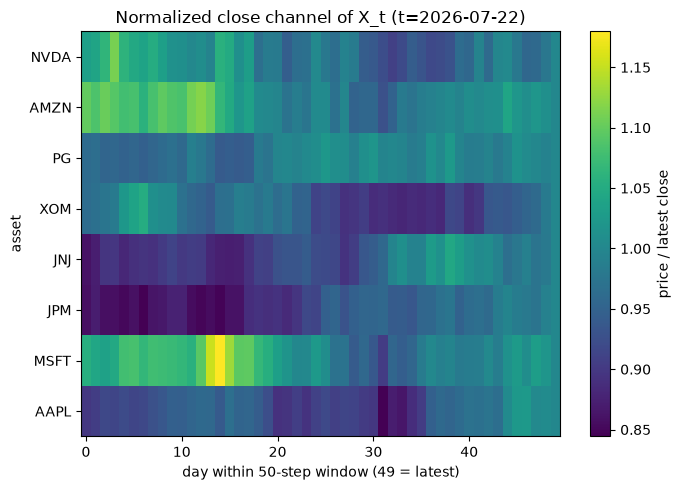

Eq. 18 OK: latest-close column == 1.0 for all assets (max dev 0.0e+00)


In [3]:
t = len(ds.dates) - 1
xt = ds.tensor(t)                       # (F, n, m)
close_ch = xt[dl.FEATURES.index('Close')]  # (n, m)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(close_ch.T, aspect='auto', cmap='viridis', origin='lower')
ax.set_title(f'Normalized close channel of X_t (t={ds.dates[t].date()})')
ax.set_xlabel('day within 50-step window (49 = latest)'); ax.set_ylabel('asset')
ax.set_yticks(range(ds.n_assets)); ax.set_yticklabels(ds.tickers)
fig.colorbar(im, ax=ax, label='price / latest close')
plt.tight_layout(); plt.show()

assert np.abs(close_ch[-1] - 1.0).max() < 1e-9
print('Eq. 18 OK: latest-close column == 1.0 for all assets '
      f'(max dev {np.abs(close_ch[-1] - 1.0).max():.1e})')

## 3. Normalized close trajectories within the window
All lines converge to 1.0 at day 49 (the normalization anchor); their spread
shows recent relative performance — exactly the signal the agent observes.

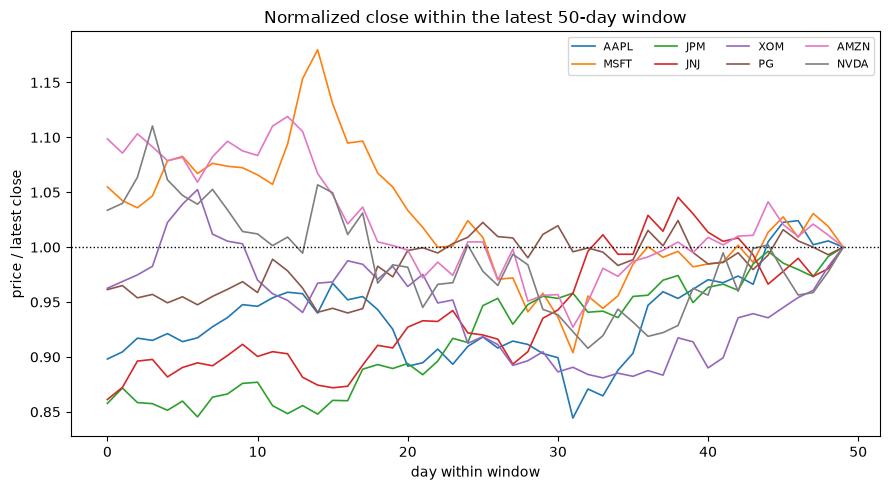

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, tkr in enumerate(ds.tickers):
    ax.plot(range(ds.window), close_ch[:, i], label=tkr, lw=1.2)
ax.axhline(1.0, color='k', ls=':', lw=1)
ax.set_title('Normalized close within the latest 50-day window')
ax.set_xlabel('day within window'); ax.set_ylabel('price / latest close')
ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

## 4. Price-relative distribution (y_t, Jiang Eq. 1)
Daily close relatives should cluster tightly around 1.0; the fat tails are real,
well-known earnings/macro days (e.g. NVDA +24% 2023-05-25, DeepSeek -17% 2025-01-27).

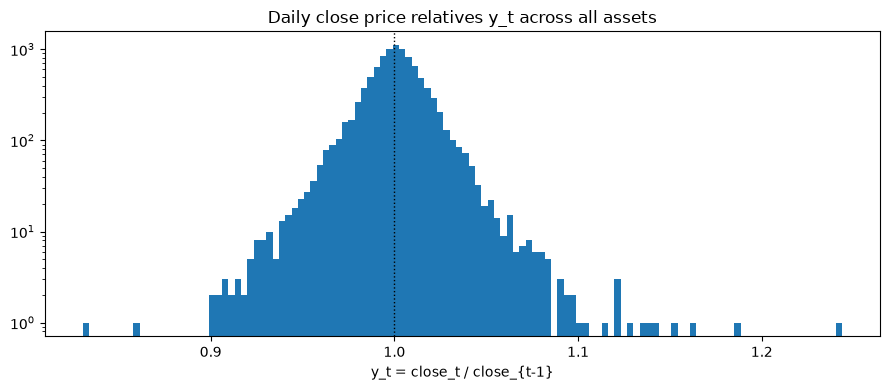

y range [0.8303, 1.2437], mean 1.00085


In [5]:
y = ds.y[1:]  # drop the t=0 placeholder
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y.ravel(), bins=120)
ax.axvline(1.0, color='k', ls=':', lw=1)
ax.set_title('Daily close price relatives y_t across all assets')
ax.set_xlabel('y_t = close_t / close_{t-1}'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print(f'y range [{y.min():.4f}, {y.max():.4f}], mean {y.mean():.5f}')